In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Add channel dimension (28, 28) -> (28, 28, 1) for Conv2D
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f'Labels: {[{i:j} for i,j in enumerate(class_names)]}')

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Labels: [{0: 'T-shirt/top'}, {1: 'Trouser'}, {2: 'Pullover'}, {3: 'Dress'}, {4: 'Coat'}, {5: 'Sandal'}, {6: 'Shirt'}, {7: 'Sneaker'}, {8: 'Bag'}, {9: 'Ankle boot'}]


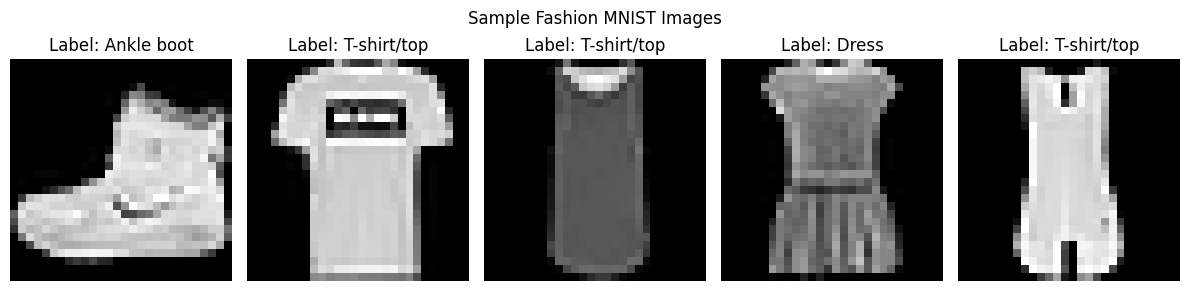

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {class_names[y_train[i]]}')
    axes[i].axis('off')
plt.suptitle('Sample Fashion MNIST Images')
plt.tight_layout()
plt.show()

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

C:\Users\om\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully.')

Model compiled successfully.


In [7]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=2
)

Epoch 1/5
844/844 - 19s - 23ms/step - accuracy: 0.8171 - loss: 0.5009 - val_accuracy: 0.8535 - val_loss: 0.3851
Epoch 2/5
844/844 - 15s - 18ms/step - accuracy: 0.8801 - loss: 0.3309 - val_accuracy: 0.8767 - val_loss: 0.3274
Epoch 3/5
844/844 - 15s - 18ms/step - accuracy: 0.8960 - loss: 0.2859 - val_accuracy: 0.8967 - val_loss: 0.2905
Epoch 4/5
844/844 - 15s - 17ms/step - accuracy: 0.9066 - loss: 0.2565 - val_accuracy: 0.8903 - val_loss: 0.2987
Epoch 5/5
844/844 - 15s - 18ms/step - accuracy: 0.9130 - loss: 0.2341 - val_accuracy: 0.9087 - val_loss: 0.2543


In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.2713
Test Accuracy: 0.9043


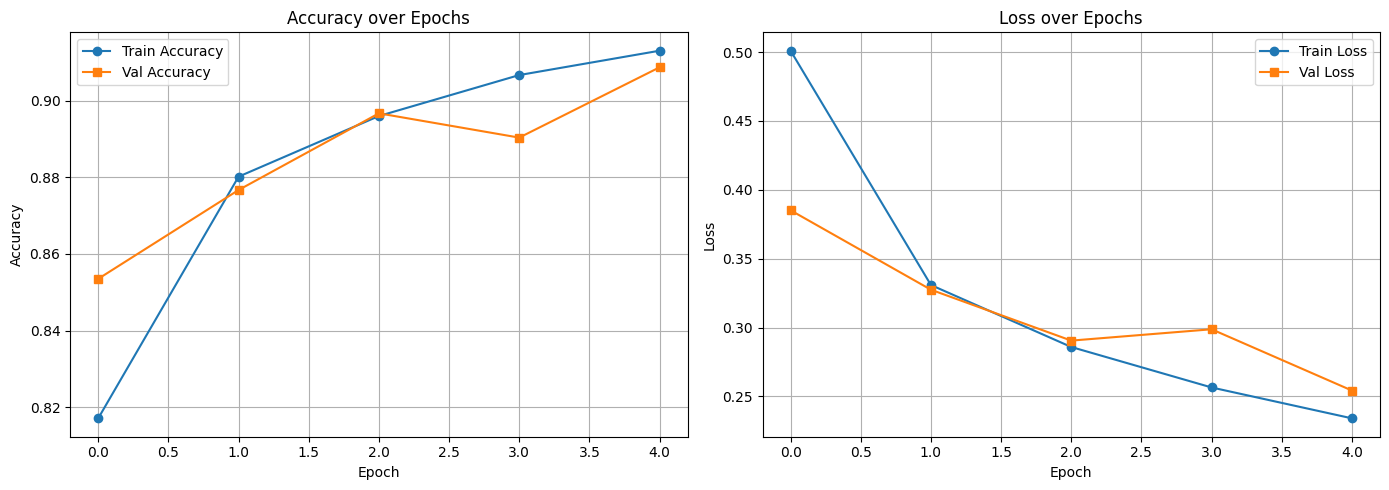

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

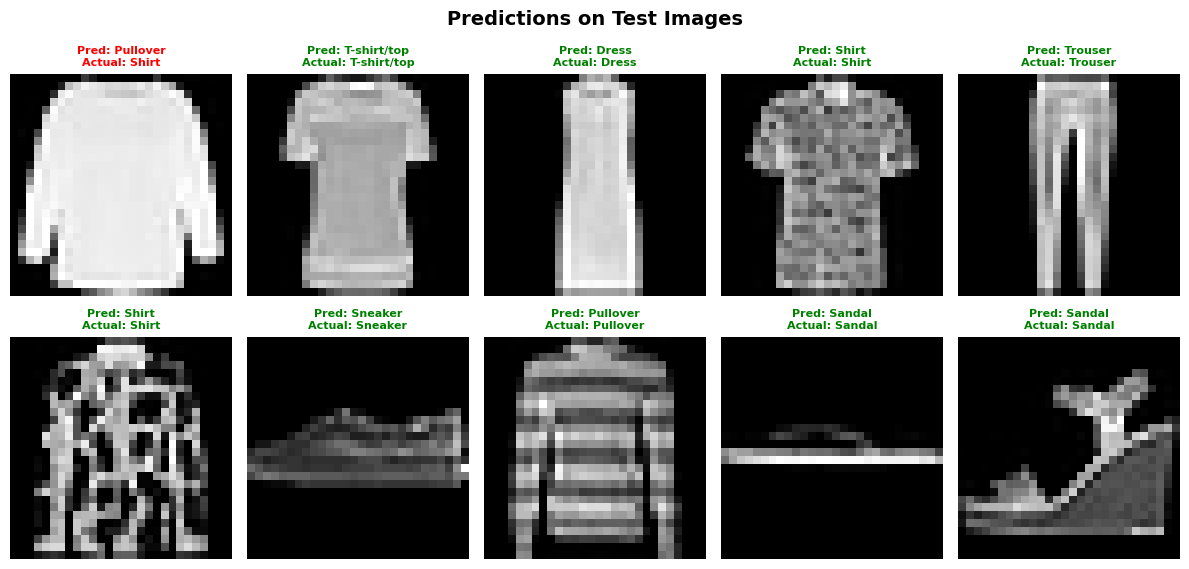

In [10]:
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
y_true = y_test.flatten()

fig, axes = plt.subplots(2, 5, figsize=(12,6))
for i in range(10):
    idx = np.random.randint(0, len(x_test))
    ax = axes[i//5, i%5]
    ax.imshow(x_test[idx].squeeze(), cmap='gray')
    predicted_class = class_names[y_pred[idx]]
    actual_class = class_names[y_true[idx]]
    color = 'green' if y_pred[idx] == y_true[idx] else 'red'
    ax.set_title(f'Pred: {predicted_class}\nActual: {actual_class}', color=color, fontweight='bold', fontsize=8)
    ax.axis('off')
plt.suptitle('Predictions on Test Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()